# Milestone 2 — Grounding Image Captions: Reducing Hallucination in Vision-Language Models
**Authors:** Naveen Manikandan (manikan2) | Varun Teja Goud Madhagouni (varuntej)  
**University at Buffalo**

In [ ]:
# Cell 1: Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cell 2: libraries

!pip install transformers==4.35.2 timm fairscale inflect --quiet

In [ ]:
# Cell 3: Project paths

import os
import sys

PROJECT_ROOT   = '/content/drive/MyDrive/BLIP_project/Hallucination-Grounding'
BLIP_DIR       = os.path.join(PROJECT_ROOT, 'BLIP')
CHAIR_DIR      = os.path.join(PROJECT_ROOT, 'chair_official')
DATA_DIR       = os.path.join(PROJECT_ROOT, 'data', 'coco')
IMG_DIR        = os.path.join(DATA_DIR, 'val2017')
ANNOT_DIR      = os.path.join(DATA_DIR, 'annotations')
RESULTS_DIR    = os.path.join(PROJECT_ROOT, 'results')
INSTANCES_FILE = os.path.join(ANNOT_DIR, 'instances_val2017.json')
CAPTIONS_FILE  = os.path.join(ANNOT_DIR, 'captions_val2017.json')

for folder in [DATA_DIR, IMG_DIR, ANNOT_DIR, RESULTS_DIR]:
    os.makedirs(folder, exist_ok=True)


In [ ]:
# Cell 4: Clone BLIP from Salesforce GitHub

if not os.path.exists(BLIP_DIR):
    !git clone https://github.com/salesforce/BLIP.git {BLIP_DIR}
    print('BLIP cloned.')
else:
    print('BLIP already exists.')

sys.path.insert(0, BLIP_DIR)

Cloning into '/content/drive/MyDrive/BLIP_project/Hallucination-Grounding/BLIP'...
remote: Enumerating objects: 283, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 283 (delta 1), reused 1 (delta 1), pack-reused 280 (from 2)
Receiving objects: 100% (283/283), 7.16 MiB | 25.04 MiB/s, done.
Resolving deltas: 100% (152/152), done.
BLIP cloned.


In [ ]:
# Cell 5: Fix BLIP import issue

file_path = os.path.join(BLIP_DIR, 'models', 'med.py')

with open(file_path, 'r') as f:
    code = f.read()

if 'from transformers.modeling_utils import apply_chunking_to_forward' in code:
    code = code.replace(
        'from transformers.modeling_utils import apply_chunking_to_forward',
        'from transformers.pytorch_utils import apply_chunking_to_forward'
    )
    with open(file_path, 'w') as f:
        f.write(code)
    print('Fixed.')
else:
    print('No fix needed.')

No fix needed.


In [ ]:
# Cell 6: Set working directory to BLIP folder

os.chdir(BLIP_DIR)
print(os.getcwd())

/content/drive/MyDrive/BLIP_project/Hallucination-Grounding/BLIP


In [ ]:
# Cell 7: Download COCO images

import zipfile
import urllib.request

def get_zip(url, save_to, extract_to):
    urllib.request.urlretrieve(url, save_to)
    with zipfile.ZipFile(save_to, 'r') as z:
        z.extractall(extract_to)
    os.remove(save_to)

imgs = [f for f in os.listdir(IMG_DIR) if f.endswith('.jpg')]

if len(imgs) < 100:
    print('Downloading images')
    get_zip(
        'http://images.cocodataset.org/zips/val2017.zip',
        os.path.join(DATA_DIR, 'val2017.zip'),
        DATA_DIR
    )
    print('Done', len(os.listdir(IMG_DIR)), 'images')
else:
    print('Already downloaded', len(imgs), 'images')

Already downloaded 5000 images


In [ ]:
# Cell 8: Download COCO annotations

if not os.path.exists(INSTANCES_FILE) or not os.path.exists(CAPTIONS_FILE):
    print('Downloading annotations')
    get_zip(
        'http://images.cocodataset.org/annotations/annotations_trainval2017.zip',
        os.path.join(DATA_DIR, 'annotations.zip'),
        DATA_DIR
    )
    print('Done')
else:
    print('Annotations already exist.')

Annotations already exist.


In [ ]:
# Cell 9: Load BLIP model

import torch
from models.blip import blip_decoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('using:', device)

model = blip_decoder(
    pretrained='https://storage.googleapis.com/sfr-vision-language-research/BLIP/models/model_base_caption_capfilt_large.pth',
    image_size=384,
    vit='base'
)
model.eval()
model = model.to(device)
print('Model loaded.')

using: cuda
load checkpoint from https://storage.googleapis.com/sfr-vision-language-research/BLIP/models/model_base_caption_capfilt_large.pth
Model loaded.


In [ ]:
# Cell 10: BLIP image transform

from torchvision import transforms
from torchvision.transforms.functional import InterpolationMode

transform = transforms.Compose([
    transforms.Resize((384, 384), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.48145466, 0.4578275, 0.40821073),
        std=(0.26862954, 0.26130258, 0.27577711)
    )
])

In [ ]:
# Cell 11: Load segmentation ground truth
import json
from collections import defaultdict

with open(INSTANCES_FILE, 'r') as f:
    instances = json.load(f)

cat_map = {c['id']: c['name'] for c in instances['categories']}

gt_objects = defaultdict(set)
for ann in instances['annotations']:
    gt_objects[ann['image_id']].add(cat_map[ann['category_id']])

fname_to_id = {img['file_name']: img['id'] for img in instances['images']}

COCO_CATS = set(cat_map.values())

print('Categories:', len(COCO_CATS))
print('Images with GT:', len(gt_objects))

Categories: 80
Images with GT: 4952


In [ ]:
# Cell 12: load official CHAIR synonym list

import inflect

if not os.path.exists(CHAIR_DIR):
    os.system(f'git clone https://github.com/LisaAnne/Hallucination.git {CHAIR_DIR}')

# find synonyms.txt wherever it is in the repo
syn_file = None
for root, dirs, files in os.walk(CHAIR_DIR):
    for f in files:
        if f == 'synonyms.txt':
            syn_file = os.path.join(root, f)
            break
    if syn_file:
        break

print('found:', syn_file)

# print first 10 lines to see the actual format
with open(syn_file, 'r') as f:
    for i, line in enumerate(f):
        print(repr(line))
        if i >= 10:
            break

found: /content/drive/MyDrive/BLIP_project/Hallucination-Grounding/chair_official/data/synonyms.txt
'person, girl, boy, man, woman, kid, child, chef, baker, people, adult, rider, children, baby, worker, passenger, sister, biker, policeman, cop, officer, lady, cowboy, bride, groom, male, female, guy, traveler, mother, father, gentleman, pitcher, player, skier, snowboarder, skater, skateboarder, person, woman, guy, foreigner, child, gentleman, caller, offender, coworker, trespasser, patient, politician, soldier, grandchild, serviceman, walker, drinker, doctor, bicyclist, thief, buyer, teenager, student, camper, driver, solider, hunter, shopper, villager\n'
'bicycle, bike, bicycle, bike, unicycle, minibike, trike\n'
'car, automobile, van, minivan, sedan, suv, hatchback, cab, jeep, coupe, taxicab, limo, taxi\n'
'motorcycle, scooter,  motor bike, motor cycle, motorbike, scooter, moped\n'
'airplane, jetliner, plane, air plane, monoplane, aircraft, jet, jetliner, airbus, biplane, seaplane\n'


In [ ]:
# Cell 13: Build synonym map for object matching

inf = inflect.engine()

def singular(w):
    r = inf.singular_noun(w)
    return r if r else w

syn_map = {}
with open(syn_file, 'r') as f:
    for line in f:
        words = [w.strip().lower() for w in line.strip().split(',')]
        if not words:
            continue
        category = words[0]
        for w in words:
            if w:
                syn_map[w] = category

print('synonym entries:', len(syn_map))
print('example - man ->', syn_map.get('man'))
print('example - bike ->', syn_map.get('bike'))
print('example - automobile ->', syn_map.get('automobile'))

synonym entries: 403
example - man -> person
example - bike -> bicycle
example - automobile -> car


In [ ]:
# Cell 14: Extract objects from text

import re

def extract_objects(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9 ]', ' ', text)
    words = [singular(w) for w in text.split()]

    found = []
    i = 0
    while i < len(words):
        matched = False
        if i + 1 < len(words):
            bi = words[i] + ' ' + words[i+1]
            if bi in syn_map and syn_map[bi] in COCO_CATS:
                found.append(syn_map[bi])
                i += 2
                matched = True
        if not matched:
            w = words[i]
            if w in syn_map and syn_map[w] in COCO_CATS:
                found.append(syn_map[w])
            i += 1
    return found

with open(CAPTIONS_FILE, 'r') as f:
    captions_data = json.load(f)

sample = captions_data['annotations'][0]['caption']
print('caption:', sample)
print('objects found:', extract_objects(sample))


caption: A black Honda motorcycle parked in front of a garage.
objects found: ['motorcycle']


In [ ]:
# Cell 15: Build combined ground truth

ref_gt = defaultdict(set)
for ann in captions_data['annotations']:
    objs = extract_objects(ann['caption'])
    ref_gt[ann['image_id']].update(objs)

combined_gt = {}
all_ids = set(gt_objects.keys()) | set(ref_gt.keys())
for img_id in all_ids:
    combined_gt[img_id] = gt_objects.get(img_id, set()) | ref_gt.get(img_id, set())

print('Images in combined GT:', len(combined_gt))

import random
for img_id in random.sample(list(combined_gt.keys()), 3):
    print('Image:', img_id)
    print('  seg GT    :', gt_objects.get(img_id, set()))
    print('  caption GT:', ref_gt.get(img_id, set()))
    print('  combined  :', combined_gt[img_id])
    print()

Images in combined GT: 5000
Image: 530146
  seg GT    : {'fork', 'dining table', 'bottle', 'knife', 'cup', 'bowl'}
  caption GT: {'dining table', 'sandwich'}
  combined  : {'bottle', 'cup', 'sandwich', 'bowl', 'fork', 'dining table', 'knife'}

Image: 459954
  seg GT    : {'person', 'refrigerator'}
  caption GT: {'person', 'refrigerator'}
  combined  : {'person', 'refrigerator'}

Image: 571857
  seg GT    : {'bicycle', 'airplane', 'bottle', 'cup', 'person', 'chair'}
  caption GT: {'person', 'chair', 'airplane'}
  combined  : {'bicycle', 'airplane', 'bottle', 'cup', 'person', 'chair'}



In [ ]:
# Cell 16: CHAIR Metric

def chair(captions, gt):
    total_caps  = len(captions)
    hall_caps   = 0
    total_objs  = 0
    hall_objs   = 0
    details     = []

    for c in captions:
        img_gt   = gt.get(c['image_id'], set())
        mentions = extract_objects(c['caption'])
        wrong    = [o for o in mentions if o not in img_gt]

        total_objs += len(mentions)
        hall_objs  += len(wrong)
        is_hall     = len(wrong) > 0
        if is_hall:
            hall_caps += 1

        details.append({
            'image_id'  : c['image_id'],
            'caption'   : c['caption'],
            'gt'        : sorted(img_gt),
            'mentioned' : mentions,
            'wrong'     : wrong,
            'hallucinated': is_hall
        })

    CHAIRs = round(hall_caps / total_caps * 100, 2) if total_caps > 0 else 0
    CHAIRi = round(hall_objs / total_objs * 100, 2) if total_objs > 0 else 0

    return {
        'CHAIRs'     : CHAIRs,
        'CHAIRi'     : CHAIRi,
        'hall_caps'  : hall_caps,
        'total_caps' : total_caps,
        'hall_objs'  : hall_objs,
        'total_objs' : total_objs,
        'details'    : details
    }


In [ ]:
# Cell 17: Select 500 images for testing

all_imgs = sorted([f for f in os.listdir(IMG_DIR) if f.endswith('.jpg')])

valid = [f for f in all_imgs
         if f in fname_to_id
         and fname_to_id[f] in combined_gt]

selected = valid[:500]

print('Total images:', len(all_imgs))
print('Images with GT:', len(valid))
print('Selected images:', len(selected))

Total images: 5000
Images with GT: 5000
Selected images: 500


In [ ]:
# Cell 18: Generate baseline captions

from PIL import Image

baseline = []

for i, fname in enumerate(selected):
    img    = Image.open(os.path.join(IMG_DIR, fname)).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model.generate(
            tensor,
            sample=False,
            num_beams=1,
            max_length=20,
            min_length=5
        )

    baseline.append({
        'image_id': fname_to_id[fname],
        'caption' : out[0]
    })

    if (i + 1) % 50 == 0:
        print(f'{i+1}/500 -- {out[0]}')

print('Done:', len(baseline), 'captions generated.')

50/500 -- a man sitting on the floor taking a picture of himself in a mirror
100/500 -- two men loading luggage into a car at an airport
150/500 -- a bus is parked on the side of the road
200/500 -- two brown bears walking on a dirt road
250/500 -- a cat is standing on a shelf in front of a television
300/500 -- a man and a woman holding wine glasses
350/500 -- a person in a red jacket skiing down a snowy hill
400/500 -- a young girl riding on the back of a horse
450/500 -- a bowl of oranges sitting on a table
500/500 -- a bird sitting on a branch with a tree in the background
Done: 500 captions generated.


In [ ]:
#Cell 19: Run CHAIR on baseline

result = chair(baseline, combined_gt)

print('Baseline CHAIR results:')
print('CHAIRs:', result['CHAIRs'], '%')
print('CHAIRi:', result['CHAIRi'], '%')
print('hallucinated captions:', result['hall_caps'], '/', result['total_caps'])
print('hallucinated objects:', result['hall_objs'], '/', result['total_objs'])

Baseline CHAIR results:
CHAIRs: 5.0 %
CHAIRi: 3.29 %
hallucinated captions: 25 / 500
hallucinated objects: 27 / 821


In [ ]:
# Cell 20 — Save baseline results

import pandas as pd

rows = [{
    'image_id'    : d['image_id'],
    'caption'     : d['caption'],
    'gt_objects'  : '|'.join(sorted(d['gt'])),
    'hallucinated': '|'.join(d['wrong']),
    'is_hall'     : d['hallucinated']
} for d in result['details']]

df = pd.DataFrame(rows)
df.to_csv(os.path.join(RESULTS_DIR, 'baseline_chair.csv'), index=False)
print('Saved:', len(df), 'rows.')
print(df[df['is_hall'] == True][['caption', 'hallucinated']].head(3))

Saved: 500 rows.
                                              caption hallucinated
4    a group of teddy bears sitting on top of a couch        couch
6   a kitchen with a refrigerator, stove, and micr...    microwave
13  a half eaten sandwich on a plate with a cup of...          cup


In [ ]:
# Cell 21 — Generate stochastic samples

import random
import numpy as np

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

sampled = []

for i, fname in enumerate(selected):
    img    = Image.open(os.path.join(IMG_DIR, fname)).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)

    caps = []
    with torch.no_grad():
        for _ in range(5):
            out = model.generate(
                tensor,
                sample=True,
                top_p=0.9,
                max_length=20,
                min_length=5
            )
            caps.append(out[0])

    sampled.append({
        'image_id' : fname_to_id[fname],
        'fname'    : fname,
        'captions' : caps
    })

    if (i + 1) % 50 == 0:
        print(f'{i+1}/500')
        for c in caps:
            print(' ', c)

print('done.', len(sampled), 'images.')


50/500
  man sitting on the floor in front of a mirror
  the man sitting on the floor taking a photo in the mirror
  the man is sitting on the floor in front of a large mirror
  a man sitting on the floor in front of a mirror
  man taking a picture in the mirror of his home
100/500
  two men loading luggage onto an airport vehicle
  two men are unloading luggage from the back of a car
  a man holding onto luggage, while another pulls him across the street
  two men pushing luggage towards the back of a car
  two men pulling luggage near their car
150/500
  a bus and some trees on the side of a street
  a street with a bus parked near it next to trees
  a city bus is driving on the road
  the yellow and black bus is on the road
  a bus is sitting at a bus stop
200/500
  two bears walking across a rocky area near brush
  two grizzly bears walk along the road in their natural habitat
  two bears walking across a sandy field near brush
  two brown bears walking on the side of a dirt road
 

In [ ]:
# Cell 22: Save sampled captions

rows = []
for s in sampled:
    row = {'image_id': s['image_id'], 'fname': s['fname']}
    for i, cap in enumerate(s['captions']):
        row[f'sample_{i+1}'] = cap
    rows.append(row)

df_s = pd.DataFrame(rows)
df_s.to_csv(os.path.join(RESULTS_DIR, 'sampled_captions.csv'), index=False)

print('saved:', len(df_s), 'rows')
print()
print('first image - all 5 samples:')
for i in range(1, 6):
    print(f'  sample {i}:', df_s[f'sample_{i}'].iloc[0])

saved: 500 rows

first image - all 5 samples:
  sample 1: a living area with a couch, a table and tv
  sample 2: the woman is standing near the table and tv
  sample 3: a woman standing in the living room area in front of a large tv
  sample 4: a living room and dining area with yellow walls
  sample 5: a television is on and a person is eating


In [ ]:
# Cell 23: Sampled caption variation analysis

import numpy as np

variation = []
for pos in range(5):
    caps = [{'image_id': s['image_id'],
             'caption' : s['captions'][pos]}
            for s in sampled]
    r = chair(caps, combined_gt)
    variation.append(r)
    print(f'sample {pos+1}: CHAIRs={r["CHAIRs"]}%  CHAIRi={r["CHAIRi"]}%')

chairs_vals = [r['CHAIRs'] for r in variation]
print()
print('variance:', round(float(np.var(chairs_vals)), 4))
print('min CHAIRs:', min(chairs_vals), '%')
print('max CHAIRs:', max(chairs_vals), '%')
print('baseline CHAIRs:', result['CHAIRs'], '%')


sample 1: CHAIRs=6.8%  CHAIRi=4.75%
sample 2: CHAIRs=3.4%  CHAIRi=2.34%
sample 3: CHAIRs=4.6%  CHAIRi=3.31%
sample 4: CHAIRs=6.0%  CHAIRi=4.08%
sample 5: CHAIRs=4.8%  CHAIRi=3.53%

variance: 1.3856
min CHAIRs: 3.4 %
max CHAIRs: 6.8 %
baseline CHAIRs: 5.0 %


In [ ]:
# Cell 24: Load CLIP Model

from transformers import CLIPModel, CLIPProcessor

clip_model     = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
clip_model     = clip_model.to(device)
clip_model.eval()


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [ ]:
# Cell 25: Hybrid scoring

def clip_score(img, caption):
    inputs = clip_processor(
        text=[caption],
        images=img,
        return_tensors='pt',
        padding=True
    ).to(device)
    with torch.no_grad():
        img_feat = clip_model.get_image_features(
            pixel_values=inputs['pixel_values'])
        txt_feat = clip_model.get_text_features(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'])
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)
        score = (img_feat * txt_feat).sum().item()
    return (score + 1) / 2

def obj_penalty(caption):
    return len(set(extract_objects(caption))) / 10.0

def len_penalty(caption):
    return max(0, len(caption.split()) - 10) / 20.0

def hybrid_score(img, caption, a=1.0, b=0.3, g=0.2):
    return (a * clip_score(img, caption)
            - b * obj_penalty(caption)
            - g * len_penalty(caption))

In [ ]:
# Cell 26: Scoring breakdown for one image

idx = 0
s = sampled[idx]
img = Image.open(os.path.join(IMG_DIR, s['fname'])).convert('RGB')
pool = [baseline[idx]['caption']] + s['captions']

print(f'Image: {s["fname"]}')
print(f'GT objects: {combined_gt[s["image_id"]]}')
print()

for j, cap in enumerate(pool):
    cs  = round(clip_score(img, cap), 4)
    op  = round(obj_penalty(cap), 4)
    lp  = round(len_penalty(cap), 4)
    hs  = round(hybrid_score(img, cap), 4)
    tag = 'baseline' if j == 0 else f'sample {j}'
    print(f'{tag}:')
    print(f'  caption : {cap}')
    print(f'  CLIP    : {cs}')
    print(f'  obj pen : {op}')
    print(f'  len pen : {lp}')
    print(f'  hybrid  : {hs}')
    print()

Image: 000000000139.jpg
GT objects: {'microwave', 'book', 'potted plant', 'tv', 'vase', 'dining table', 'refrigerator', 'clock', 'person', 'chair'}

baseline:
  caption : a woman standing in a living room with a television
  CLIP    : 0.6409
  obj pen : 0.2
  len pen : 0.0
  hybrid  : 0.5809

sample 1:
  caption : a living area with a couch, a table and tv
  CLIP    : 0.6247
  obj pen : 0.3
  len pen : 0.0
  hybrid  : 0.5347

sample 2:
  caption : the woman is standing near the table and tv
  CLIP    : 0.6377
  obj pen : 0.3
  len pen : 0.0
  hybrid  : 0.5477

sample 3:
  caption : a woman standing in the living room area in front of a large tv
  CLIP    : 0.6414
  obj pen : 0.2
  len pen : 0.2
  hybrid  : 0.5414

sample 4:
  caption : a living room and dining area with yellow walls
  CLIP    : 0.6434
  obj pen : 0.0
  len pen : 0.0
  hybrid  : 0.6434

sample 5:
  caption : a television is on and a person is eating
  CLIP    : 0.6171
  obj pen : 0.2
  len pen : 0.0
  hybrid  : 0.5571



In [ ]:
# Cell 27: Apply Selection

clip_selected   = []
hybrid_selected = []

for i, s in enumerate(sampled):
    img  = Image.open(os.path.join(IMG_DIR, s['fname'])).convert('RGB')
    pool = [baseline[i]['caption']] + s['captions']

    # clip only selection
    best_clip, best_clip_score = None, -999
    for cap in pool:
        sc = clip_score(img, cap)
        if sc > best_clip_score:
            best_clip_score = sc
            best_clip = cap

    # hybrid selection
    best_hybrid, best_hybrid_score = None, -999
    for cap in pool:
        sc = hybrid_score(img, cap)
        if sc > best_hybrid_score:
            best_hybrid_score = sc
            best_hybrid = cap

    clip_selected.append({'image_id': s['image_id'], 'caption': best_clip})
    hybrid_selected.append({'image_id': s['image_id'], 'caption': best_hybrid})

    if (i + 1) % 50 == 0:
        print(f'{i+1}/500')
        print(f'  baseline : {baseline[i]["caption"]}')
        print(f'  CLIP     : {best_clip}')
        print(f'  hybrid   : {best_hybrid}')

50/500
  baseline : a man sitting on the floor taking a picture of himself in a mirror
  CLIP     : a man sitting on the floor in front of a mirror
  hybrid   : man sitting on the floor in front of a mirror
100/500
  baseline : two men loading luggage into a car at an airport
  CLIP     : two men loading luggage into a car at an airport
  hybrid   : two men loading luggage onto an airport vehicle
150/500
  baseline : a bus is parked on the side of the road
  CLIP     : a bus is sitting at a bus stop
  hybrid   : a bus is sitting at a bus stop
200/500
  baseline : two brown bears walking on a dirt road
  CLIP     : two brown bears walking on a dirt road
  hybrid   : two brown bears walking on a dirt road
250/500
  baseline : a cat is standing on a shelf in front of a television
  CLIP     : a white and brown cat stands on a table near a tv
  hybrid   : cat standing on tv stand watching television
300/500
  baseline : a man and a woman holding wine glasses
  CLIP     : a man and woman ar

In [ ]:
# Cell 28: Run CHAIR on all three methods

clip_result   = chair(clip_selected,   combined_gt)
hybrid_result = chair(hybrid_selected, combined_gt)

print('Results on 500 COCO images:')
print()
print(f'Baseline  CHAIRs={result["CHAIRs"]}%  CHAIRi={result["CHAIRi"]}%')
print(f'CLIP only CHAIRs={clip_result["CHAIRs"]}%  CHAIRi={clip_result["CHAIRi"]}%')
print(f'Hybrid    CHAIRs={hybrid_result["CHAIRs"]}%  CHAIRi={hybrid_result["CHAIRi"]}%')


Results on 500 COCO images:

Baseline  CHAIRs=5.0%  CHAIRi=3.29%
CLIP only CHAIRs=6.8%  CHAIRi=4.43%
Hybrid    CHAIRs=0.8%  CHAIRi=0.79%


In [ ]:
# Cell 29: Hybrid result metrics

def avg_stats(caption_list):
    lengths = [len(c['caption'].split()) for c in caption_list]
    objects = [len(extract_objects(c['caption'])) for c in caption_list]
    return {
        'avg_length' : round(sum(lengths) / len(lengths), 2),
        'avg_objects': round(sum(objects) / len(objects), 2)
    }

b_stats = avg_stats(baseline)
c_stats = avg_stats(clip_selected)
h_stats = avg_stats(hybrid_selected)

print('Method       CHAIRs  CHAIRi  AvgLen  AvgObj')
print('-' * 50)
print(f'Baseline     {result["CHAIRs"]}%   {result["CHAIRi"]}%   {b_stats["avg_length"]}   {b_stats["avg_objects"]}')
print(f'CLIP only    {clip_result["CHAIRs"]}%   {clip_result["CHAIRi"]}%   {c_stats["avg_length"]}   {c_stats["avg_objects"]}')
print(f'Hybrid       {hybrid_result["CHAIRs"]}%   {hybrid_result["CHAIRi"]}%   {h_stats["avg_length"]}   {h_stats["avg_objects"]}')

Method       CHAIRs  CHAIRi  AvgLen  AvgObj
--------------------------------------------------
Baseline     5.0%   3.29%   9.61   1.64
CLIP only    6.8%   4.43%   10.21   1.53
Hybrid       0.8%   0.79%   9.19   1.01


In [ ]:
# Cell 30: Save CLIP and Hybrid results

def save_result(result, fname):
    rows = [{
        'image_id': d['image_id'],
        'caption' : d['caption'],
        'gt'      : '|'.join(sorted(d['gt'])),
        'wrong'   : '|'.join(d['wrong']),
        'is_hall' : d['hallucinated']
    } for d in result['details']]
    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(RESULTS_DIR, fname), index=False)
    print(fname, '-', df['is_hall'].sum(), 'hallucinated out of', len(df))

save_result(clip_result,   'clip_chair.csv')
save_result(hybrid_result, 'hybrid_chair.csv')


clip_chair.csv - 34 hallucinated out of 500
hybrid_chair.csv - 4 hallucinated out of 500


In [ ]:
 # Cell 31:  Summary

 summary = pd.DataFrame([
    {'method': 'baseline',
     'CHAIRs': result['CHAIRs'],
     'CHAIRi': result['CHAIRi'],
     'hall_captions': result['hall_caps'],
     'total_captions': result['total_caps']},
    {'method': 'clip_only',
     'CHAIRs': clip_result['CHAIRs'],
     'CHAIRi': clip_result['CHAIRi'],
     'hall_captions': clip_result['hall_caps'],
     'total_captions': clip_result['total_caps']},
    {'method': 'hybrid',
     'CHAIRs': hybrid_result['CHAIRs'],
     'CHAIRi': hybrid_result['CHAIRi'],
     'hall_captions': hybrid_result['hall_caps'],
     'total_captions': hybrid_result['total_caps']}
])

summary.to_csv(os.path.join(RESULTS_DIR, 'summary.csv'), index=False)
print('saved: summary.csv')
print()
print(summary.to_string(index=False))

saved: summary.csv

   method  CHAIRs  CHAIRi  hall_captions  total_captions
 baseline     5.0    3.29             25             500
clip_only     6.8    4.43             34             500
   hybrid     0.8    0.79              4             500


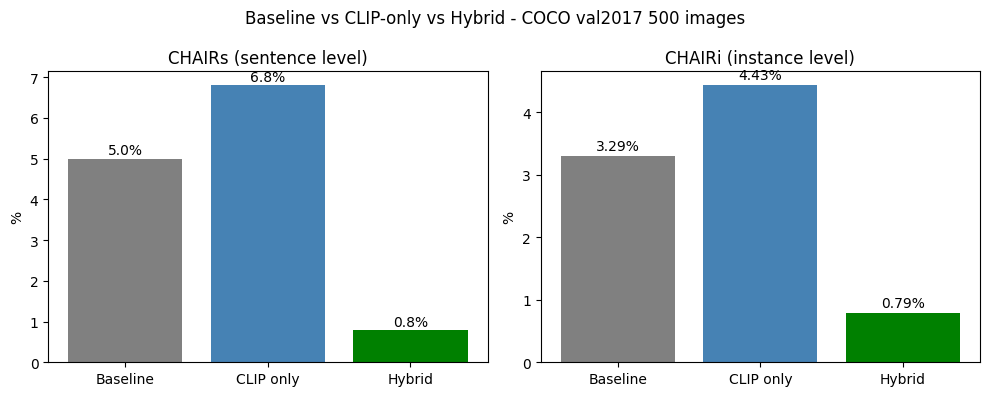

In [ ]:
# Cell 32: Comparison plot

import matplotlib.pyplot as plt
from collections import Counter

methods = ['Baseline', 'CLIP only', 'Hybrid']
chairs  = [result['CHAIRs'], clip_result['CHAIRs'], hybrid_result['CHAIRs']]
chairi  = [result['CHAIRi'], clip_result['CHAIRi'], hybrid_result['CHAIRi']]
colors  = ['gray', 'steelblue', 'green']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, vals, title in [
    (axes[0], chairs, 'CHAIRs (sentence level)'),
    (axes[1], chairi, 'CHAIRi (instance level)')
]:
    ax.bar(methods, vals, color=colors)
    ax.set_title(title)
    ax.set_ylabel('%')
    for i, v in enumerate(vals):
        ax.text(i, v + 0.1, f'{v}%', ha='center')

fig.suptitle('Baseline vs CLIP-only vs Hybrid - COCO val2017 500 images')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'plot1_comparison.png'), dpi=150)
plt.show()


images improved by hybrid: 24


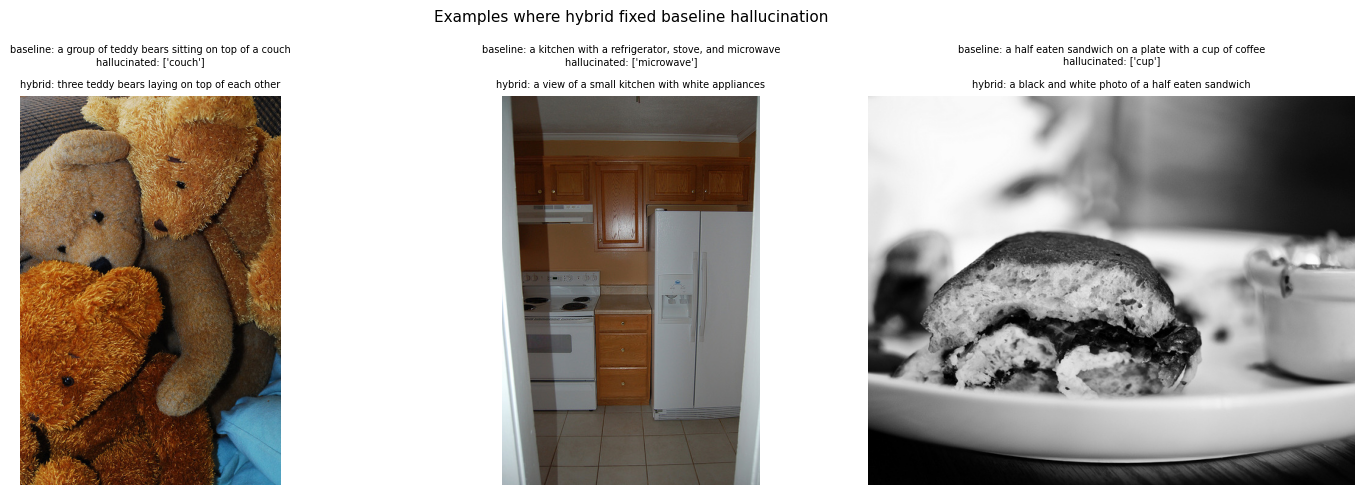

In [ ]:
# Cell 33: Plot baseline vs Hybrid

baseline_hall  = {d['image_id']: d for d in result['details'] if d['hallucinated']}
hybrid_clean   = {d['image_id']: d for d in hybrid_result['details'] if not d['hallucinated']}

improved = [img_id for img_id in baseline_hall if img_id in hybrid_clean]
print('images improved by hybrid:', len(improved))

examples = improved[:3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

id_to_fname = {v: k for k, v in fname_to_id.items()}

for ax, img_id in zip(axes, examples):
    fname  = id_to_fname[img_id]
    img    = Image.open(os.path.join(IMG_DIR, fname)).convert('RGB')
    b_cap  = baseline_hall[img_id]['caption']
    h_cap  = hybrid_clean[img_id]['caption']
    wrong  = baseline_hall[img_id]['wrong']

    ax.imshow(img)
    ax.set_title(
        f'baseline: {b_cap}\nhallucinated: {wrong}\n\nhybrid: {h_cap}',
        fontsize=7, color='black'
    )
    ax.axis('off')

fig.suptitle('Examples where hybrid fixed baseline hallucination', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'plot5_examples.png'), dpi=150)
plt.show()